In [1]:
#import relevant libraries
#Load modules
import os
import pandas as pd
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns
import dabest
from struct import *
import osar
import scipy as sp
import re
import dabest
import warnings
import scikits.bootstrap as skb
from osar.plot_helpers.plot_helpers import r2_and_slope

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

#warnings.simplefilter(action="default", category=RuntimeWarning)

import matplotlib as mpl
from matplotlib import font_manager

# Custom font (optional)
font_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 14.71it/s]


Numba compilation complete!


## 1. Load and Prepare Data

In [2]:
# Load all CSV files from 2025collection folder
import os
from pathlib import Path

data_folder = Path(r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled\2025collection")

# Get all CSV files, excluding R76B09
csv_files = [f for f in data_folder.glob("*.csv") if "R76B09" not in f.name]

print(f"Found {len(csv_files)} CSV files (excluding R76B09)")

# Load all data
all_data = []
for csv_file in csv_files:
    df_temp = pd.read_csv(csv_file, index_col=0)
    # Extract cross name from filename (e.g., "MB018B x ACR")
    cross_name = csv_file.stem  # removes .csv
    df_temp['cross_name'] = cross_name
    
    # Extract driver and responder from cross name
    parts = cross_name.split(' x ')
    df_temp['driver_name'] = parts[0]
    df_temp['responder_name'] = parts[1] if len(parts) > 1 else ''
    
    all_data.append(df_temp)

df = pd.concat(all_data, ignore_index=True)

Found 64 CSV files (excluding R76B09)


In [3]:
# Separate driver/+ and responder/+ controls
# Driver/+ = w1118 x [DRIVER_NAME] (e.g., w1118 x MB018B)
# Responder/+ = w1118 x ACR or w1118 x Chrimson2

# Filter for Full light intensity only
df_full = df[df['light_intensity'] == 'Full'].copy()

# Identify control types
def get_control_type(row):
    genotype = row['genotype']
    if genotype.startswith('w1118 x '):
        control_part = genotype.replace('w1118 x ', '')
        if control_part in ['ACR', 'Chrimson2']:
            return 'responder_control'  # w1118 x ACR or w1118 x Chrimson2
        else:
            return 'driver_control'  # w1118 x [DRIVER]
    else:
        return 'test'  # experimental cross

df_full['control_type'] = df_full.apply(get_control_type, axis=1)

# Separate the controls
df_driver_ctrl = df_full[df_full['control_type'] == 'driver_control'].copy()
df_responder_ctrl = df_full[df_full['control_type'] == 'responder_control'].copy()

print(f"\nUnique driver/+ genotypes: {df_driver_ctrl['genotype'].unique()}")
print(f"\nUnique responder/+ genotypes: {df_responder_ctrl['genotype'].unique()}")


Unique driver/+ genotypes: ['w1118 x MB018B' 'w1118 x MB077B' 'w1118 x MB082C' 'w1118 x MB093C'
 'w1118 x MB112C' 'w1118 x MB210B' 'w1118 x MB242A' 'w1118 x MB310C'
 'w1118 x MB319C' 'w1118 x MB323B' 'w1118 x MB434B' 'w1118 x SS01188'
 'w1118 x SS01194' 'w1118 x SS01298' 'w1118 x SS46348' 'w1118 x SS52050'
 'w1118 x SS67662' 'w1118 x SS67741' 'w1118 x SS75199' 'w1118 x SS75200'
 'w1118 x SS77383' 'w1118 x SS77442' 'w1118 x SS77450' 'w1118 x SS80896'
 'w1118 x SS80958' 'w1118 x SS81353' 'w1118 x SS46438' 'w1118 x SS81521'
 'w1118 x SS86947' 'w1118 x SS95118' 'w1118 x VT999036']

Unique responder/+ genotypes: ['w1118 x ACR' 'w1118 x Chrimson2']


In [36]:
# Compute mean and 95% CI for each cross's controls
from scipy import stats

def compute_group_stats(group, value_col='pi_smoothed_Pattern 01'):
    """Compute mean, SEM, and 95% CI for a group"""
    values = group[value_col].dropna()
    n = len(values)
    if n == 0:
        return pd.Series({'mean_value': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'n': 0, 'std': np.nan})
    
    mean = np.mean(values)
    
    if n > 1:
        sem = stats.sem(values)
        ci_margin = sem * stats.t.ppf(0.975, n-1)
        ci_low = mean - ci_margin
        ci_high = mean + ci_margin
        std = np.std(values, ddof=1)
    else:
        ci_low = mean
        ci_high = mean
        std = 0
    
    return pd.Series({
        'mean_value': mean,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'n': n,
        'std': std
    })

# Compute stats for responder/+ controls grouped by cross
df_responder_stats = df_responder_ctrl.groupby(['cross_name', 'responder_name', 'genotype']).apply(
    compute_group_stats
).reset_index()

# Compute stats for driver/+ controls grouped by cross
df_driver_stats = df_driver_ctrl.groupby(['cross_name', 'driver_name', 'genotype']).apply(
    compute_group_stats
).reset_index()


C:\Users\user\AppData\Local\Temp\ipykernel_60432\2009832928.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_responder_stats = df_responder_ctrl.groupby(['cross_name', 'responder_name', 'genotype']).apply(
C:\Users\user\AppData\Local\Temp\ipykernel_60432\2009832928.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_driver_stats = df_driver_ctrl.groupby(['cross_name', 'driver_name', 'genotype']).

## 2. Plot 1: Responder/+ Controls Across All Crosses
Compare all w1118 x ACR and w1118 x Chrimson2 controls to see if there's variation across different crosses.

In [37]:
def plot_scatter_with_ci(ax, x_positions, means, ci_lows, ci_highs, 
                         marker_color='darkblue', marker_size=50,
                         ci_linewidth=1.5, ci_capsize=3):
    """Plot scatter points with CI error bars"""
    # Convert to numpy arrays for arithmetic operations
    x_positions = np.array(x_positions)
    means = np.array(means)
    ci_lows = np.array(ci_lows)
    ci_highs = np.array(ci_highs)
    
    yerr_lower = means - ci_lows
    yerr_upper = ci_highs - means
    yerr = [yerr_lower, yerr_upper]
    
    ax.errorbar(x_positions, means, yerr=yerr,
                fmt='none', ecolor=marker_color, 
                elinewidth=ci_linewidth, capsize=ci_capsize, capthick=ci_linewidth,
                zorder=1)
    
    ax.scatter(x_positions, means, s=marker_size, color=marker_color, 
               zorder=2, edgecolors='white', linewidths=0.5)
    return ax


def plot_grouped_comparison(ax, df_driver, df_responder, 
                            driver_color='#2e6f40', responder_color='#cf0c16',
                            marker_size=50, ci_linewidth=1.5, ci_capsize=3,
                            group_spacing=1.0, within_group_spacing=0.3):
    """
    Plot driver/+ vs responder/+ grouped by cross
    
    Returns x_positions and labels for customization
    """
    # Get unique crosses (sorted)
    crosses = sorted(df_driver['cross_name'].unique())
    
    x_positions_driver = []
    x_positions_responder = []
    group_centers = []
    labels = []
    
    current_x = 0
    for cross in crosses:
        driver_data = df_driver[df_driver['cross_name'] == cross]
        responder_data = df_responder[df_responder['cross_name'] == cross]
        
        if len(driver_data) > 0 and len(responder_data) > 0:
            # Position driver on left, responder on right within group
            x_driver = current_x
            x_responder = current_x + within_group_spacing
            
            x_positions_driver.append(x_driver)
            x_positions_responder.append(x_responder)
            group_centers.append((x_driver + x_responder) / 2)
            labels.append(cross)
            
            # Plot driver/+
            plot_scatter_with_ci(ax, [x_driver], 
                                [driver_data['mean_value'].values[0]],
                                [driver_data['ci_low'].values[0]],
                                [driver_data['ci_high'].values[0]],
                                marker_color=driver_color, marker_size=marker_size,
                                ci_linewidth=ci_linewidth, ci_capsize=ci_capsize)
            
            # Plot responder/+
            plot_scatter_with_ci(ax, [x_responder], 
                                [responder_data['mean_value'].values[0]],
                                [responder_data['ci_low'].values[0]],
                                [responder_data['ci_high'].values[0]],
                                marker_color=responder_color, marker_size=marker_size,
                                ci_linewidth=ci_linewidth, ci_capsize=ci_capsize)
            
            current_x += group_spacing + within_group_spacing
    
    return group_centers, labels, x_positions_driver, x_positions_responder

ACR responder/+ controls: 27 crosses


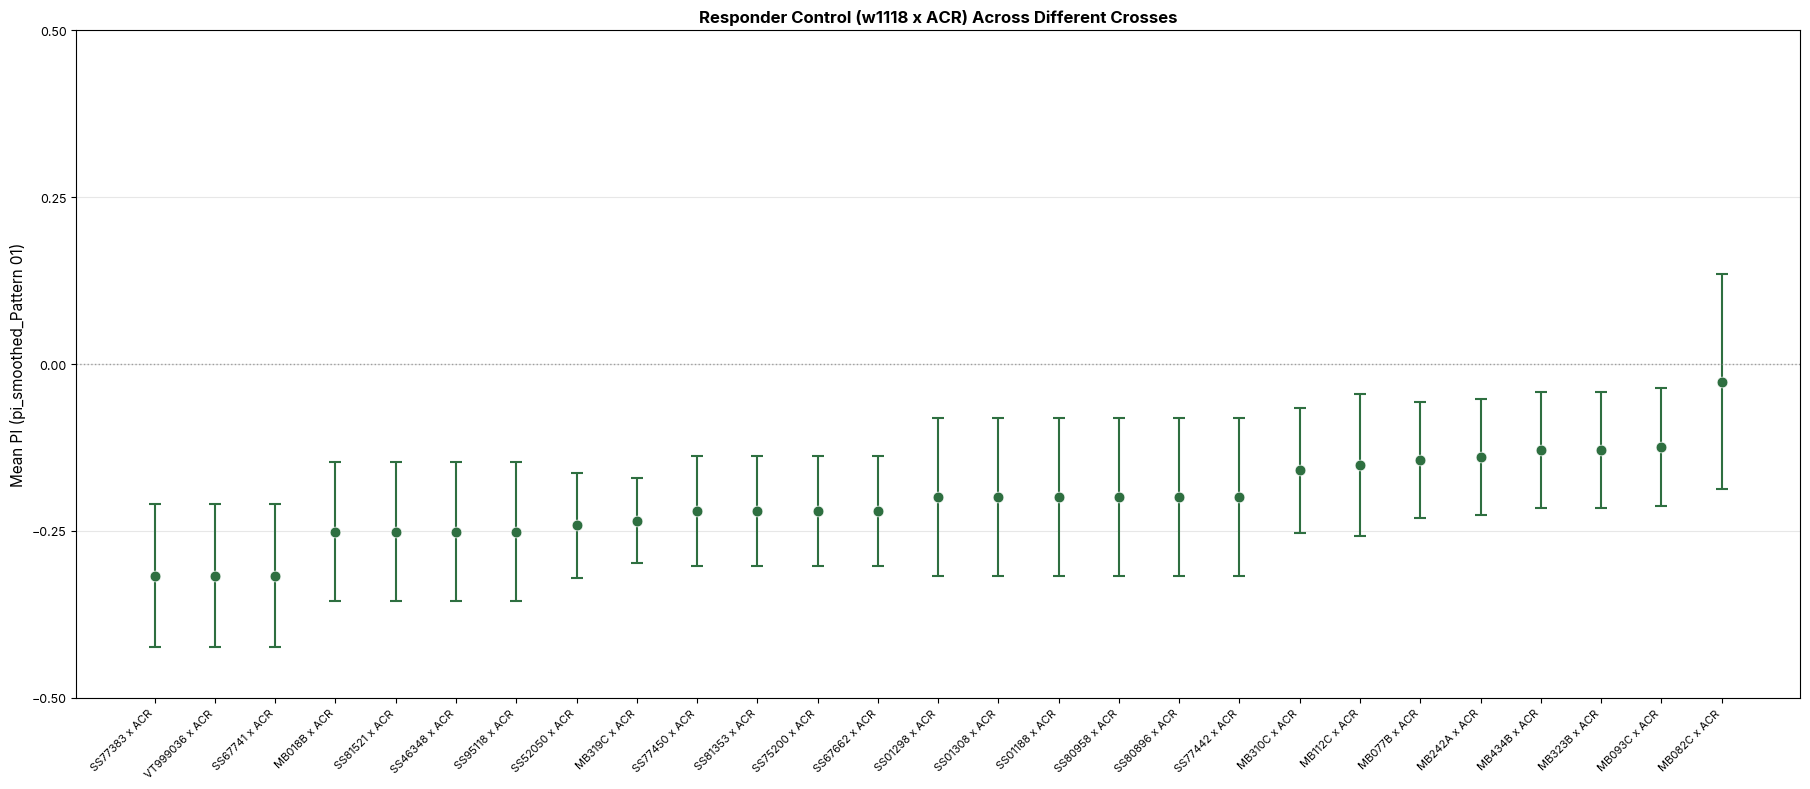

In [38]:
# Plot 1a: All w1118 x ACR (responder/+) controls across different crosses
df_acr_resp = df_responder_stats[df_responder_stats['responder_name'] == 'ACR'].copy()
df_acr_resp = df_acr_resp.sort_values('mean_value').reset_index(drop=True)

print(f"ACR responder/+ controls: {len(df_acr_resp)} crosses")

# === CUSTOMIZABLE PARAMETERS ===
fig_width = len(df_acr_resp) * 0.6 + 2
fig_height = 8
marker_color = '#2e6f40'
marker_size = 60
ci_linewidth = 1.5
ci_capsize = 4
ylim = (-0.5, 0.5)
yticks = [-0.5, -0.25, 0, 0.25, 0.5]

# Labels
title = 'Responder Control (w1118 x ACR) Across Different Crosses'
title_fontsize = 12
title_fontweight = 'bold'
ylabel = 'Mean PI (pi_smoothed_Pattern 01)'
ylabel_fontsize = 11
xtick_fontsize = 8
xtick_rotation = 45
ytick_fontsize = 9

# Zero line
zero_line_style = ':'
zero_line_color = 'gray'

# Grid
show_grid = True
grid_axis = 'y'
grid_alpha = 0.3
# ================================

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

x_positions = np.arange(len(df_acr_resp))

# Plot
plot_scatter_with_ci(ax, x_positions, 
                     df_acr_resp['mean_value'].values,
                     df_acr_resp['ci_low'].values,
                     df_acr_resp['ci_high'].values,
                     marker_color=marker_color, marker_size=marker_size,
                     ci_linewidth=ci_linewidth, ci_capsize=ci_capsize)

# Zero line
ax.axhline(y=0, color=zero_line_color, linestyle=zero_line_style, linewidth=1, alpha=0.7)

# Customizations
ax.set_xticks(x_positions)
ax.set_xticklabels(df_acr_resp['cross_name'], fontsize=xtick_fontsize, rotation=xtick_rotation, ha='right')
ax.tick_params(axis='y', labelsize=ytick_fontsize)
ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
ax.set_ylim(ylim)
if yticks:
    ax.set_yticks(yticks)
if show_grid:
    ax.grid(axis=grid_axis, alpha=grid_alpha)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Chrimson2 responder/+ controls: 31 crosses


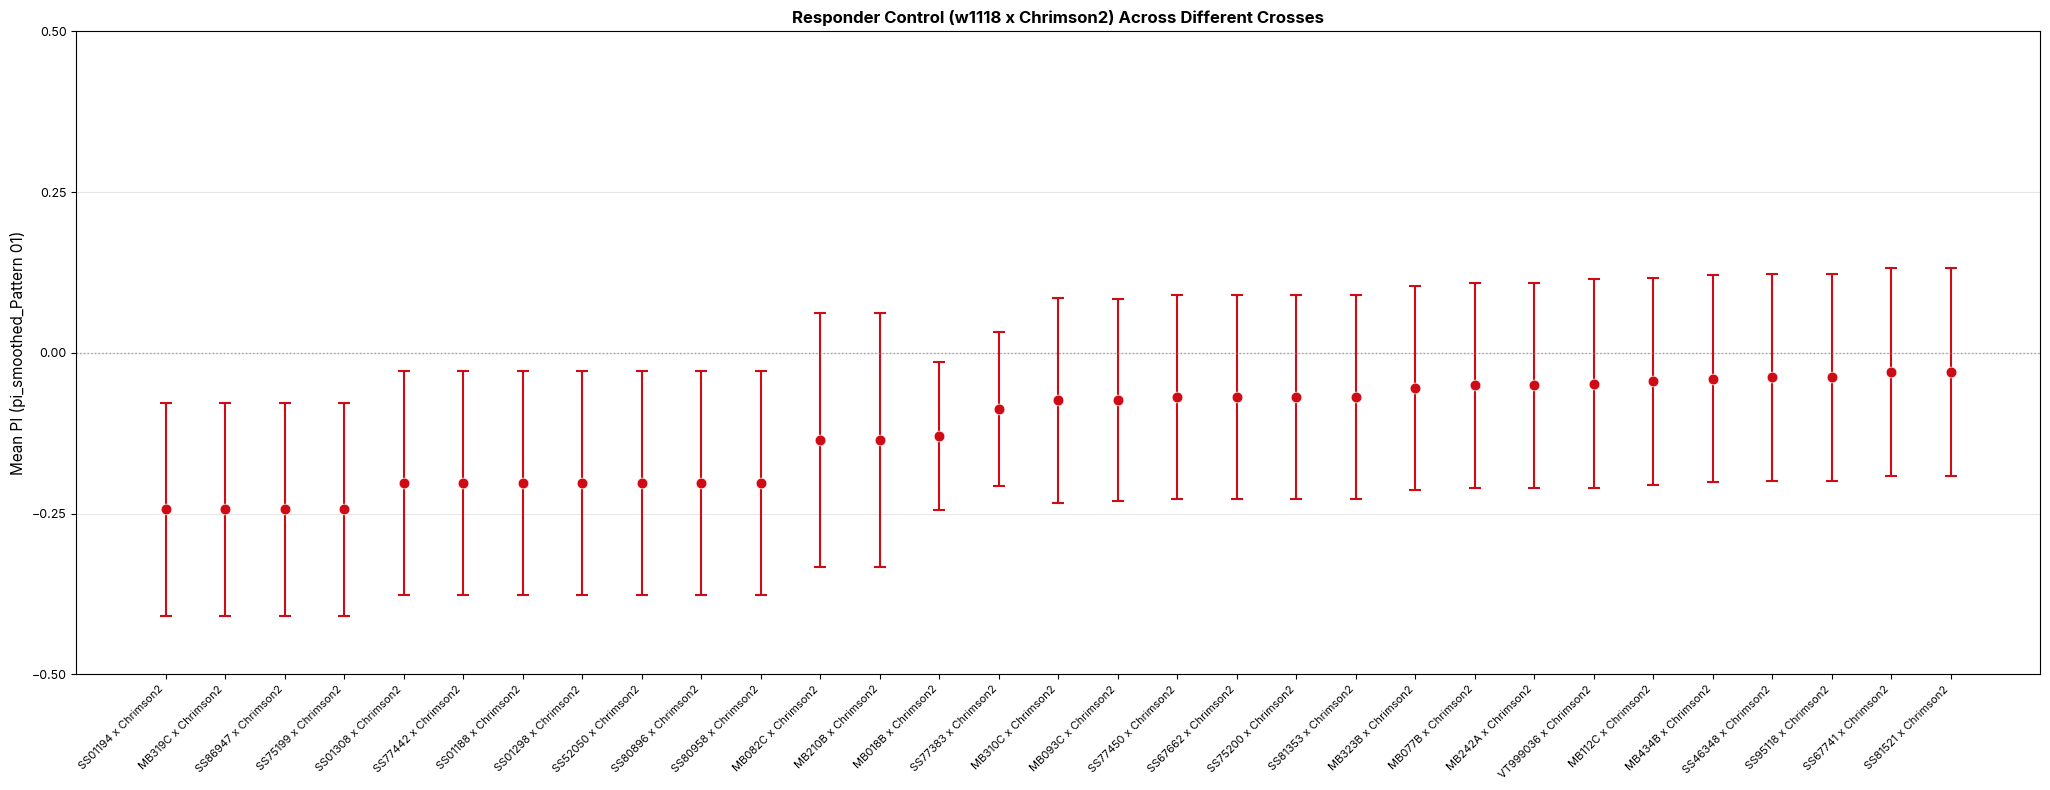

In [39]:
# Plot 1b: All w1118 x Chrimson2 (responder/+) controls across different crosses
df_chrim_resp = df_responder_stats[df_responder_stats['responder_name'] == 'Chrimson2'].copy()
df_chrim_resp = df_chrim_resp.sort_values('mean_value').reset_index(drop=True)

print(f"Chrimson2 responder/+ controls: {len(df_chrim_resp)} crosses")

# === CUSTOMIZABLE PARAMETERS ===
fig_width = len(df_chrim_resp) * 0.6 + 2
fig_height = 8
marker_color = '#cf0c16'
marker_size = 60
ci_linewidth = 1.5
ci_capsize = 4
ylim = (-0.5, 0.5)
yticks = [-0.5, -0.25, 0, 0.25, 0.5]

# Labels
title = 'Responder Control (w1118 x Chrimson2) Across Different Crosses'
title_fontsize = 12
title_fontweight = 'bold'
ylabel = 'Mean PI (pi_smoothed_Pattern 01)'
ylabel_fontsize = 11
xtick_fontsize = 8
xtick_rotation = 45
ytick_fontsize = 9

# Zero line
zero_line_style = ':'
zero_line_color = 'gray'

# Grid
show_grid = True
grid_axis = 'y'
grid_alpha = 0.3
# ================================

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

x_positions = np.arange(len(df_chrim_resp))

# Plot
plot_scatter_with_ci(ax, x_positions, 
                     df_chrim_resp['mean_value'].values,
                     df_chrim_resp['ci_low'].values,
                     df_chrim_resp['ci_high'].values,
                     marker_color=marker_color, marker_size=marker_size,
                     ci_linewidth=ci_linewidth, ci_capsize=ci_capsize)

# Zero line
ax.axhline(y=0, color=zero_line_color, linestyle=zero_line_style, linewidth=1, alpha=0.7)

# Customizations
ax.set_xticks(x_positions)
ax.set_xticklabels(df_chrim_resp['cross_name'], fontsize=xtick_fontsize, rotation=xtick_rotation, ha='right')
ax.tick_params(axis='y', labelsize=ytick_fontsize)
ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
ax.set_ylim(ylim)
if yticks:
    ax.set_yticks(yticks)
if show_grid:
    ax.grid(axis=grid_axis, alpha=grid_alpha)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Plot 2: Driver/+ vs Responder/+ Grouped by Cross
Compare w1118 x [DRIVER] (driver/+) to w1118 x [RESPONDER] (responder/+) for each genetic cross, grouped together.

ACR crosses: 19


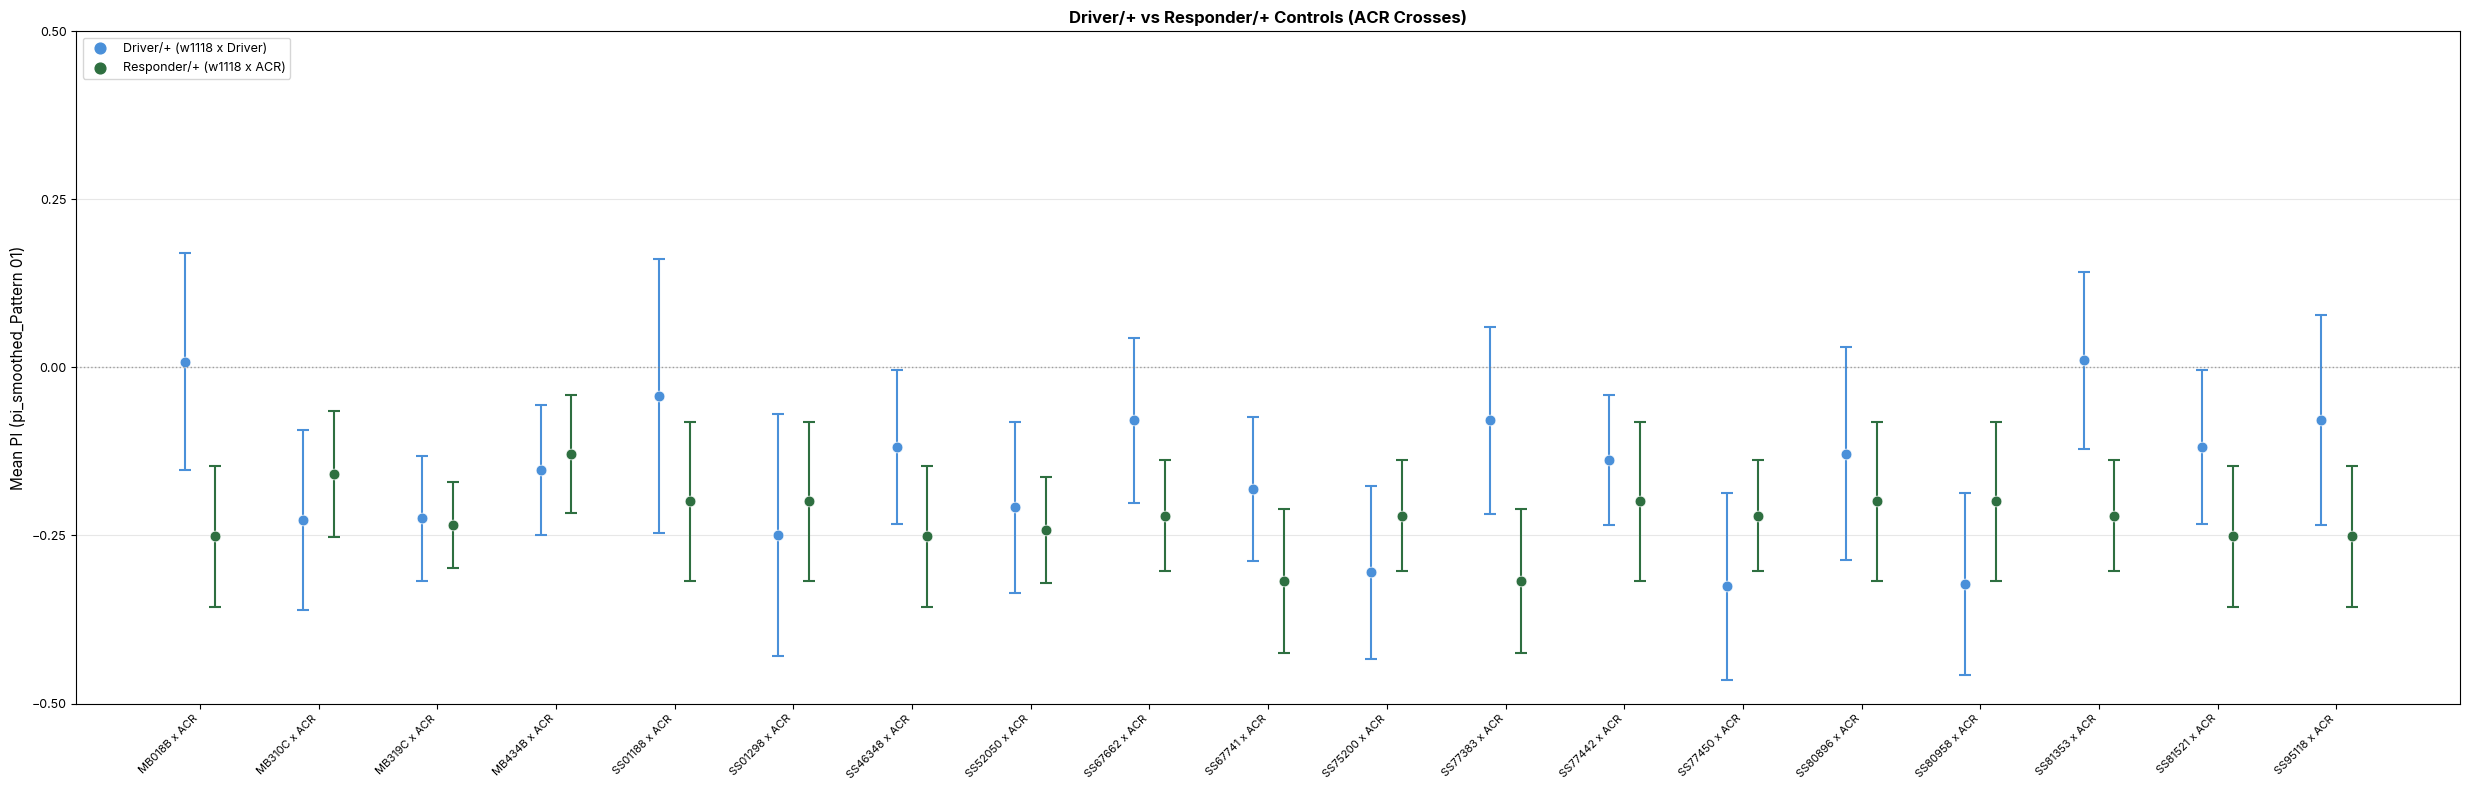

In [40]:
# Plot 2a: Driver/+ vs Responder/+ for ACR crosses
df_acr_driver = df_driver_stats[df_driver_stats['cross_name'].str.contains(' x ACR')].copy()
df_acr_responder = df_responder_stats[df_responder_stats['responder_name'] == 'ACR'].copy()

# Sort by driver mean
df_acr_driver = df_acr_driver.sort_values('mean_value').reset_index(drop=True)
cross_order = df_acr_driver['cross_name'].tolist()

print(f"ACR crosses: {len(cross_order)}")

# === CUSTOMIZABLE PARAMETERS ===
fig_width = len(cross_order) * 1.2 + 2
fig_height = 8
driver_color = '#4a90d9'  # Blue for driver/+
responder_color = '#2e6f40'  # Green for responder/+ (ACR)
marker_size = 60
ci_linewidth = 1.5
ci_capsize = 4
group_spacing = 1.0  # Space between groups
within_group_spacing = 0.35  # Space between driver and responder within a group
ylim = (-0.5, 0.5)
yticks = [-0.5, -0.25, 0, 0.25, 0.5]

# Labels
title = 'Driver/+ vs Responder/+ Controls (ACR Crosses)'
title_fontsize = 12
title_fontweight = 'bold'
ylabel = 'Mean PI (pi_smoothed_Pattern 01)'
ylabel_fontsize = 11
xtick_fontsize = 8
xtick_rotation = 45
ytick_fontsize = 9

# Zero line
zero_line_style = ':'
zero_line_color = 'gray'

# Grid
show_grid = True
grid_axis = 'y'
grid_alpha = 0.3
# ================================

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Plot grouped comparison
group_centers, labels, x_driver, x_responder = plot_grouped_comparison(
    ax, df_acr_driver, df_acr_responder,
    driver_color=driver_color, responder_color=responder_color,
    marker_size=marker_size, ci_linewidth=ci_linewidth, ci_capsize=ci_capsize,
    group_spacing=group_spacing, within_group_spacing=within_group_spacing
)

# Zero line
ax.axhline(y=0, color=zero_line_color, linestyle=zero_line_style, linewidth=1, alpha=0.7)

# Customizations
ax.set_xticks(group_centers)
ax.set_xticklabels(labels, fontsize=xtick_fontsize, rotation=xtick_rotation, ha='right')
ax.tick_params(axis='y', labelsize=ytick_fontsize)
ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
ax.set_ylim(ylim)
if yticks:
    ax.set_yticks(yticks)
if show_grid:
    ax.grid(axis=grid_axis, alpha=grid_alpha)
    ax.set_axisbelow(True)

# Legend
ax.scatter([], [], color=driver_color, s=marker_size, label='Driver/+ (w1118 x Driver)')
ax.scatter([], [], color=responder_color, s=marker_size, label='Responder/+ (w1118 x ACR)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Plot 2b: Driver/+ vs Responder/+ for Chrimson2 Crosses

Chrimson2 crosses: 28


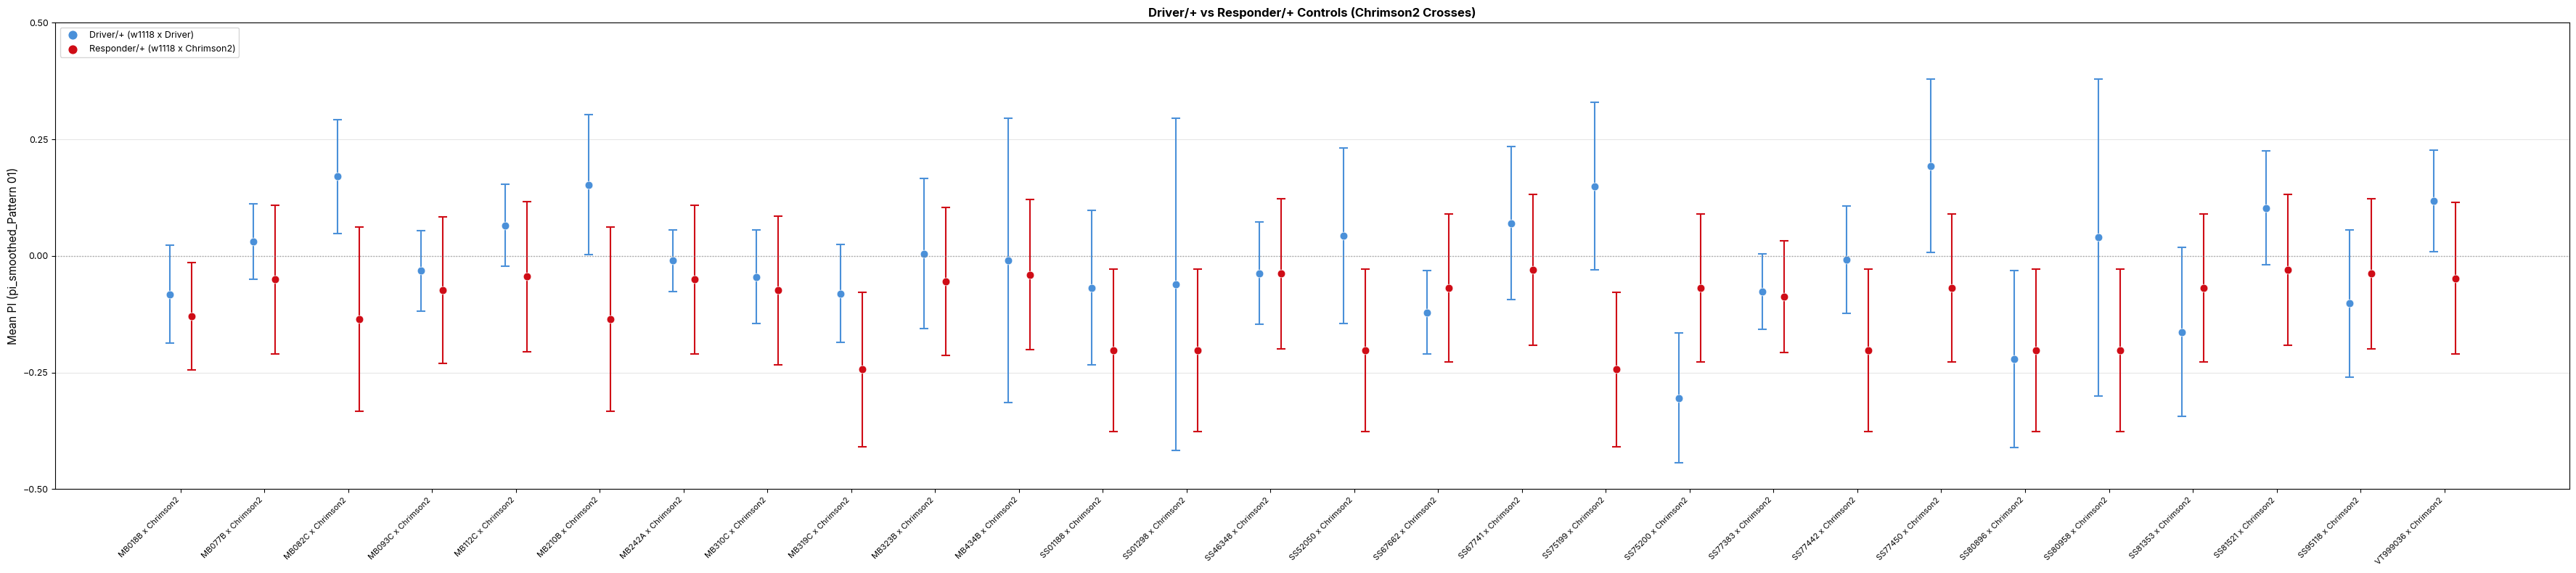

In [41]:
# Plot 2b: Driver/+ vs Responder/+ for Chrimson2 crosses
df_chrim_driver = df_driver_stats[df_driver_stats['cross_name'].str.contains(' x Chrimson2')].copy()
df_chrim_responder = df_responder_stats[df_responder_stats['responder_name'] == 'Chrimson2'].copy()

# Sort by driver mean
df_chrim_driver = df_chrim_driver.sort_values('mean_value').reset_index(drop=True)
cross_order_chrim = df_chrim_driver['cross_name'].tolist()

print(f"Chrimson2 crosses: {len(cross_order_chrim)}")

# === CUSTOMIZABLE PARAMETERS ===
fig_width = len(cross_order_chrim) * 1.2 + 2
fig_height = 8
driver_color = '#4a90d9'  # Blue for driver/+
responder_color = '#cf0c16'  # Red for responder/+ (Chrimson2)
marker_size = 60
ci_linewidth = 1.5
ci_capsize = 4
group_spacing = 1.0
within_group_spacing = 0.35
ylim = (-0.5, 0.5)
yticks = [-0.5, -0.25, 0, 0.25, 0.5]

# Labels
title = 'Driver/+ vs Responder/+ Controls (Chrimson2 Crosses)'
title_fontsize = 12
title_fontweight = 'bold'
ylabel = 'Mean PI (pi_smoothed_Pattern 01)'
ylabel_fontsize = 11
xtick_fontsize = 8
xtick_rotation = 45
ytick_fontsize = 9

# Zero line
zero_line_style = ':'
zero_line_color = 'gray'

# Grid
show_grid = True
grid_axis = 'y'
grid_alpha = 0.3
# ================================

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Plot grouped comparison
group_centers, labels, x_driver, x_responder = plot_grouped_comparison(
    ax, df_chrim_driver, df_chrim_responder,
    driver_color=driver_color, responder_color=responder_color,
    marker_size=marker_size, ci_linewidth=ci_linewidth, ci_capsize=ci_capsize,
    group_spacing=group_spacing, within_group_spacing=within_group_spacing
)

# Zero line
ax.axhline(y=0, color=zero_line_color, linestyle=zero_line_style, linewidth=1, alpha=0.7)

# Customizations
ax.set_xticks(group_centers)
ax.set_xticklabels(labels, fontsize=xtick_fontsize, rotation=xtick_rotation, ha='right')
ax.tick_params(axis='y', labelsize=ytick_fontsize)
ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight)
ax.set_ylim(ylim)
if yticks:
    ax.set_yticks(yticks)
if show_grid:
    ax.grid(axis=grid_axis, alpha=grid_alpha)
    ax.set_axisbelow(True)

# Legend
ax.scatter([], [], color=driver_color, s=marker_size, label='Driver/+ (w1118 x Driver)')
ax.scatter([], [], color=responder_color, s=marker_size, label='Responder/+ (w1118 x Chrimson2)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 4. DABEST Analysis: Hedges' g Heatmap (Responder/+ vs Driver/+)
Compare responder/+ (first group) vs driver/+ (second group) for each cross using DABEST unpaired analysis with Hedges' g effect size.

In [5]:
# Prepare data for DABEST analysis
# We need individual fly data with control_type labels for each cross

# Create a combined dataframe with control type for DABEST
df_controls = df_full[df_full['control_type'].isin(['driver_control', 'responder_control'])].copy()

# Create a cleaner group label
df_controls['group_label'] = df_controls['control_type'].map({
    'responder_control': 'Responder/+',
    'driver_control': 'Driver/+'
})

df_controls.groupby(['cross_name', 'group_label']).size().unstack(fill_value=0)

group_label,Driver/+,Responder/+
cross_name,,
MB018B x ACR,29,72
MB018B x Chrimson2,38,118
MB077B x ACR,0,101
MB077B x Chrimson2,56,58
MB082C x ACR,0,36
...,...,...
SS95118 x Chrimson2,30,58
SS97567 x ACR,0,45
SS97567 x Chrimson2,0,74


In [6]:
# Run DABEST analysis for each cross: Responder/+ vs Driver/+
# Responder/+ is the first group (control), Driver/+ is the second group (test)

dabest_results = []

for cross_name in sorted(df_controls['cross_name'].unique()):
    cross_data = df_controls[df_controls['cross_name'] == cross_name].copy()
    
    # Check we have both groups
    groups_present = cross_data['group_label'].unique()
    if 'Responder/+' not in groups_present or 'Driver/+' not in groups_present:
        print(f"Skipping {cross_name}: missing one or both control groups")
        continue
    
    # Get responder type for this cross
    responder_type = cross_data[cross_data['group_label'] == 'Responder/+']['genotype'].iloc[0]
    responder_type = responder_type.replace('w1118 x ', '')  # ACR or Chrimson2
    
    # Get driver name
    driver_name = cross_name.split(' x ')[0]
    
    try:
        # Load into DABEST - Responder/+ first, Driver/+ second
        dabest_obj = dabest.load(
            cross_data,
            x='group_label',
            y='pi_smoothed_Pattern 01',
            idx=('Responder/+', 'Driver/+')  # Responder first (control), Driver second (test)
        )
        
        # Compute Hedges' g
        hedges_g_result = dabest_obj.hedges_g.results
        
        # Extract values
        effect_size = hedges_g_result['difference'].values[0]
        ci_low = hedges_g_result['bca_low'].values[0]
        ci_high = hedges_g_result['bca_high'].values[0]
        pvalue = hedges_g_result['pvalue_permutation'].values[0]
        
        dabest_results.append({
            'cross_name': cross_name,
            'driver': driver_name,
            'responder': responder_type,
            'hedges_g': effect_size,
            'ci_low': ci_low,
            'ci_high': ci_high,
            'pvalue': pvalue,
            'n_responder': len(cross_data[cross_data['group_label'] == 'Responder/+']),
            'n_driver': len(cross_data[cross_data['group_label'] == 'Driver/+'])
        })
        
    except Exception as e:
        print(f"Error processing {cross_name}: {e}")

df_dabest = pd.DataFrame(dabest_results)
print(f"\nDABEST analysis completed for {len(df_dabest)} crosses")
df_dabest.head(10)

Skipping MB077B x ACR: missing one or both control groups
Skipping MB082C x ACR: missing one or both control groups
Skipping MB093C x ACR: missing one or both control groups
Skipping MB112C x ACR: missing one or both control groups
Skipping MB242A x ACR: missing one or both control groups
Skipping MB323B x ACR: missing one or both control groups
Skipping SS01194 x Chrimson2: missing one or both control groups
Skipping SS01308 x ACR: missing one or both control groups
Skipping SS01308 x Chrimson2: missing one or both control groups
Skipping SS86947 x Chrimson2: missing one or both control groups
Skipping SS97567 x ACR: missing one or both control groups
Skipping SS97567 x Chrimson2: missing one or both control groups
Skipping VT999036 x ACR: missing one or both control groups

DABEST analysis completed for 51 crosses


,cross_name,driver,responder,hedges_g,ci_low,ci_high,pvalue,n_responder,n_driver
0,MB018B x ACR,MB018B,ACR,0.586778,0.145005,1.011920,0.0066,72,29
1,MB018B x Chrimson2,MB018B,Chrimson2,0.081146,-0.171878,0.364758,0.6616,118,38
2,MB077B x Chrimson2,MB077B,Chrimson2,0.169410,-0.187321,0.529236,0.3634,58,56
3,MB082C x Chrimson2,MB082C,Chrimson2,0.518908,0.127497,0.926561,0.0054,44,80
4,MB093C x Chrimson2,MB093C,Chrimson2,0.085940,-0.266112,0.455219,0.6430,58,71
5,MB112C x Chrimson2,MB112C,Chrimson2,0.220820,-0.139077,0.582947,0.2368,58,59
6,MB210B x ACR,MB210B,ACR,0.057146,-0.265569,0.390576,0.7252,101,60
7,MB210B x Chrimson2,MB210B,Chrimson2,0.470511,0.042204,0.872735,0.0234,44,59
8,MB242A x Chrimson2,MB242A,Chrimson2,0.087252,-0.278258,0.452222,0.6430,58,60
9,MB310C x ACR,MB310C,ACR,-0.151773,-0.523544,0.210836,0.4370,45,60


In [47]:
# Create heatmap of Hedges' g: Drivers (rows) vs Responders (columns)
# Pivot the data to create a matrix

df_heatmap = df_dabest.pivot(index='driver', columns='responder', values='hedges_g')

# Also create CI matrices for annotations
df_ci_low = df_dabest.pivot(index='driver', columns='responder', values='ci_low')
df_ci_high = df_dabest.pivot(index='driver', columns='responder', values='ci_high')
df_pvalue = df_dabest.pivot(index='driver', columns='responder', values='pvalue')

# Sort drivers by mean Hedges' g (across responders)
driver_order = df_heatmap.mean(axis=1).sort_values().index.tolist()
df_heatmap = df_heatmap.loc[driver_order]
df_ci_low = df_ci_low.loc[driver_order]
df_ci_high = df_ci_high.loc[driver_order]
df_pvalue = df_pvalue.loc[driver_order]

df_heatmap

responder,ACR,Chrimson2
driver,,
SS75200,-0.188433,-0.411026
MB310C,-0.151773,0.055457
MB434B,-0.056709,0.051257
SS80958,-0.318808,0.361075
SS01298,-0.130435,0.210600
SS80896,0.173859,-0.028948
SS77450,-0.226408,0.390714
MB093C,NaN,0.085940
MB242A,NaN,0.087252


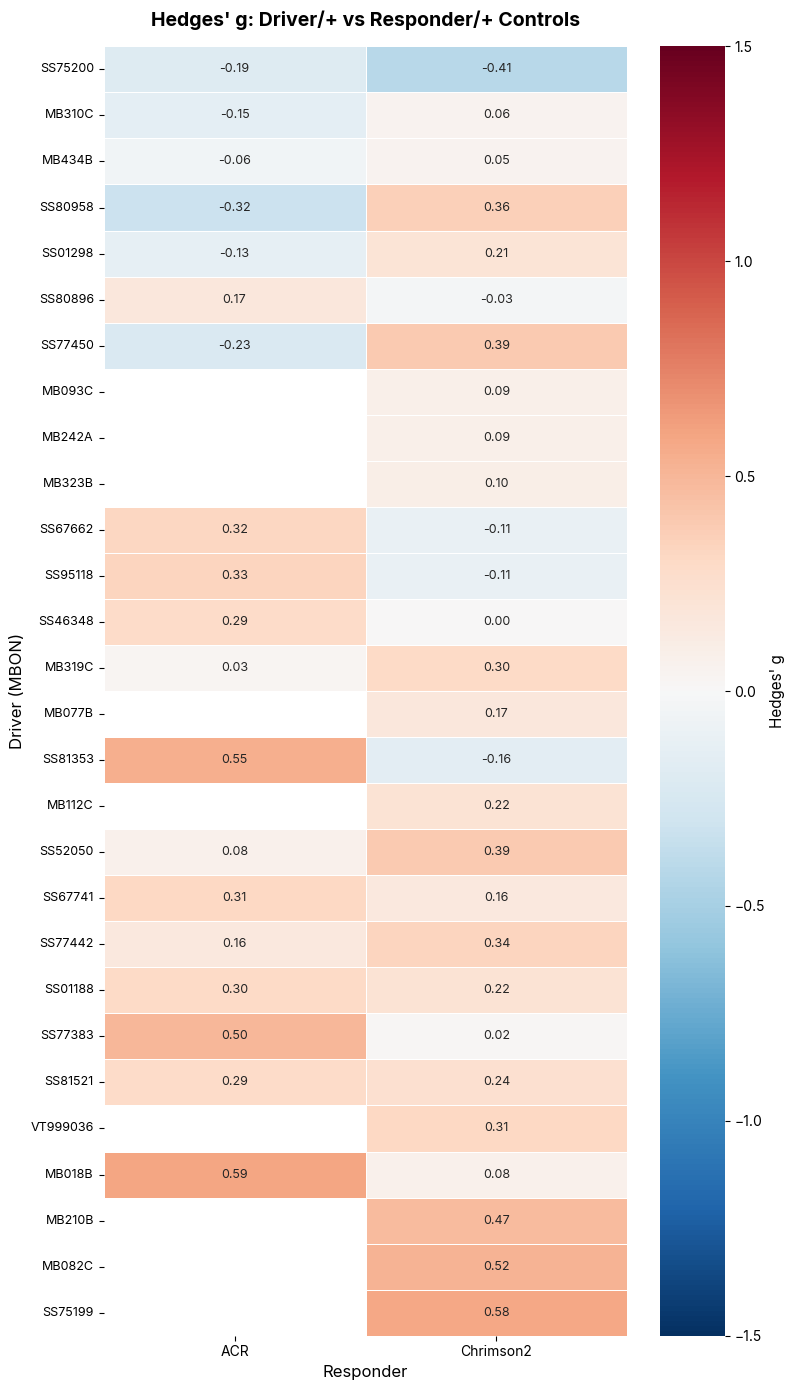

In [48]:
# Plot Hedges' g Heatmap with annotations

# === CUSTOMIZABLE PARAMETERS ===
fig_width = 8
fig_height = max(len(df_heatmap) * 0.5, 8)

# Colormap settings
cmap = 'RdBu_r'  # Red-Blue diverging (red = positive, blue = negative)
vmin = -1.5
vmax = 1.5
center = 0

# Annotation settings
annot = True
annot_fmt = '.2f'  # Format for annotation values
annot_fontsize = 9
annot_color_threshold = 0.8  # Switch text color when |value| > threshold

# Labels
title = "Hedges' g: Driver/+ vs Responder/+ Controls"
title_fontsize = 14
title_fontweight = 'bold'
xlabel = 'Responder'
ylabel = 'Driver (MBON)'
xlabel_fontsize = 12
ylabel_fontsize = 12
xtick_fontsize = 10
ytick_fontsize = 9

# Colorbar
cbar_label = "Hedges' g"
cbar_fontsize = 11
# ================================

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Create heatmap using seaborn
hm = sns.heatmap(
    df_heatmap,
    ax=ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    center=center,
    annot=annot,
    fmt=annot_fmt,
    annot_kws={'fontsize': annot_fontsize},
    cbar_kws={'label': cbar_label},
    linewidths=0.5,
    linecolor='white'
)

# Customize labels
ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight, pad=15)

# Tick label formatting
ax.tick_params(axis='x', labelsize=xtick_fontsize, rotation=0)
ax.tick_params(axis='y', labelsize=ytick_fontsize, rotation=0)

# Colorbar label
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label(cbar_label, fontsize=cbar_fontsize)

plt.tight_layout()
plt.show()

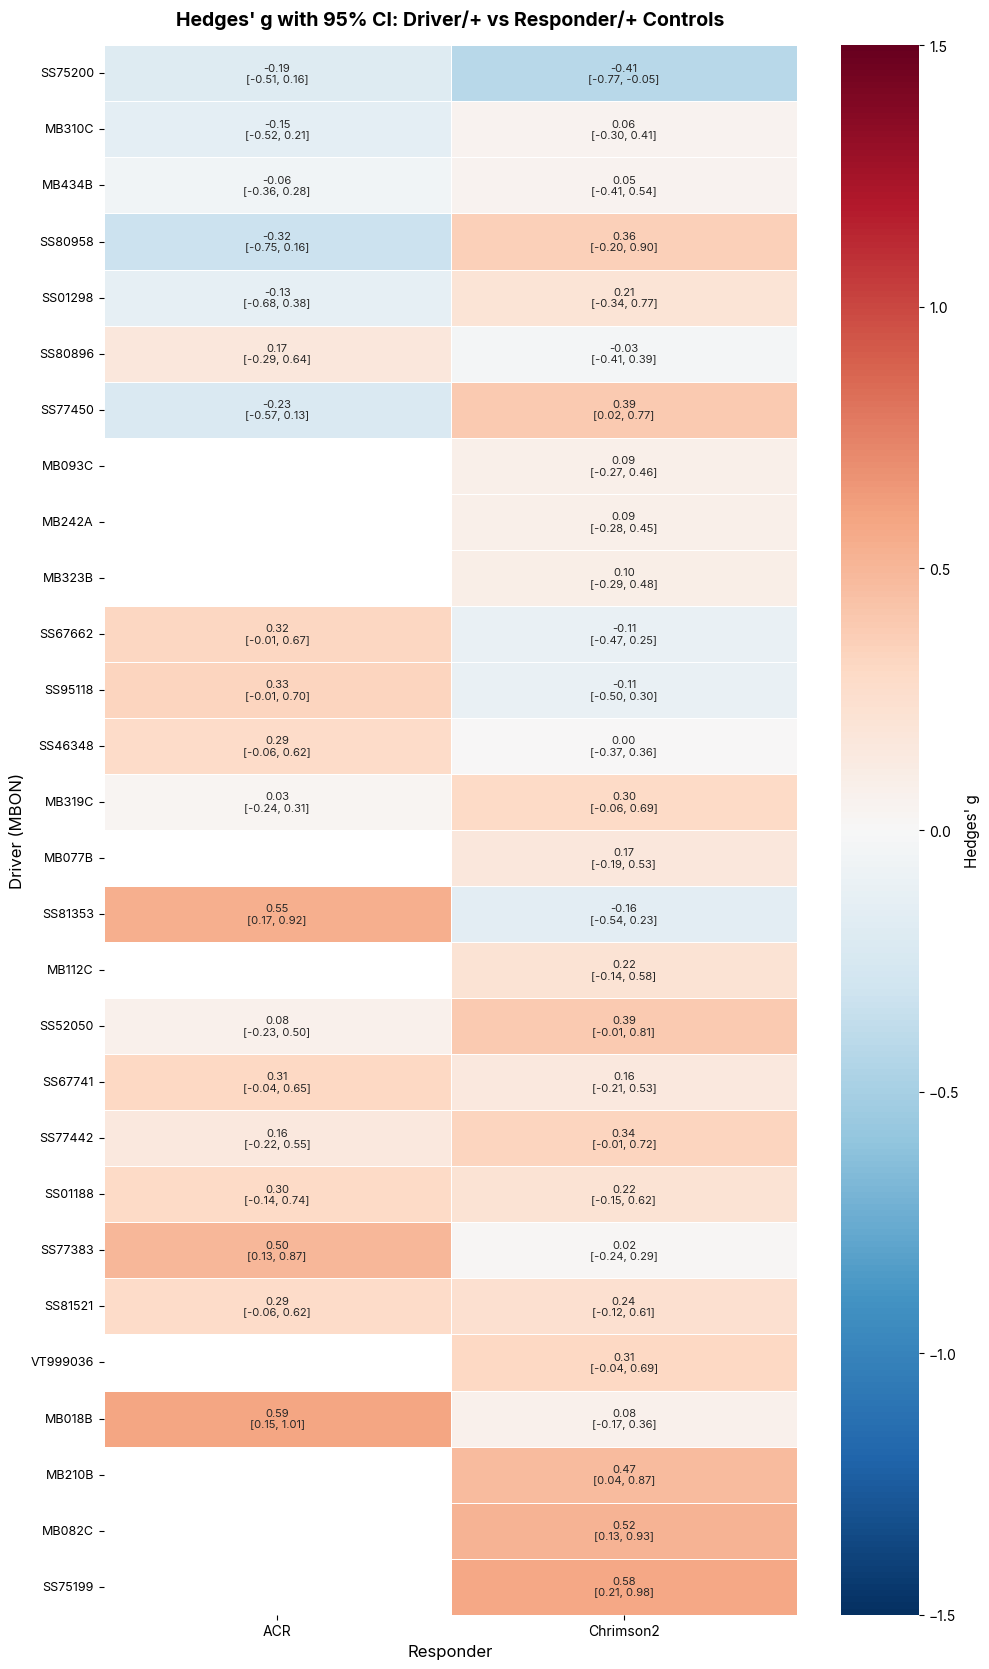

In [49]:
# Alternative: Heatmap with Hedges' g and CI annotations

# Create annotation strings with CI
annot_with_ci = df_heatmap.copy().astype(str)
for driver in df_heatmap.index:
    for resp in df_heatmap.columns:
        val = df_heatmap.loc[driver, resp]
        ci_l = df_ci_low.loc[driver, resp]
        ci_h = df_ci_high.loc[driver, resp]
        if pd.notna(val):
            annot_with_ci.loc[driver, resp] = f'{val:.2f}\n[{ci_l:.2f}, {ci_h:.2f}]'
        else:
            annot_with_ci.loc[driver, resp] = ''

# === CUSTOMIZABLE PARAMETERS ===
fig_width = 10
fig_height = max(len(df_heatmap) * 0.6, 10)

# Colormap settings
cmap = 'RdBu_r'
vmin = -1.5
vmax = 1.5
center = 0

# Annotation settings
annot_fontsize = 8

# Labels
title = "Hedges' g with 95% CI: Driver/+ vs Responder/+ Controls"
title_fontsize = 14
title_fontweight = 'bold'
xlabel = 'Responder'
ylabel = 'Driver (MBON)'
xlabel_fontsize = 12
ylabel_fontsize = 12
xtick_fontsize = 10
ytick_fontsize = 9

# Colorbar
cbar_label = "Hedges' g"
cbar_fontsize = 11
# ================================

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Create heatmap with CI annotations
hm = sns.heatmap(
    df_heatmap,
    ax=ax,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    center=center,
    annot=annot_with_ci,
    fmt='',  # Empty format since we're using strings
    annot_kws={'fontsize': annot_fontsize, 'va': 'center'},
    cbar_kws={'label': cbar_label},
    linewidths=0.5,
    linecolor='white'
)

# Customize labels
ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
ax.set_title(title, fontsize=title_fontsize, fontweight=title_fontweight, pad=15)

# Tick label formatting
ax.tick_params(axis='x', labelsize=xtick_fontsize, rotation=0)
ax.tick_params(axis='y', labelsize=ytick_fontsize, rotation=0)

# Colorbar label
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label(cbar_label, fontsize=cbar_fontsize)

plt.tight_layout()
plt.show()